# AG-HYPOPT · Trial 10

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_10. Nine trials recorded. Target plateau (h_f 3.5-5.5) samples : exp6 0.0803
(4.0/3.675), trial_05 0.0818 (3.58/5.78), trial_09 0.0859 (4.05/7.57), trial_01 0.0837 (5.35/7.65), trial_08
0.0882 (3.78/7.28), trial_06 0.0890 (3.68/5.32); edges worse (trial_07 0.1165 @ h_f 1.13, trial_04 0.0926 @
9.82); sim 0.1249; power 0.1541. Best recorded is still exp6's 0.0803. A weak (within-SE) trend suggests the
smallest-h_s plateau point (exp6, h_s 3.675) is best, but no result is significant at SE ~0.021-0.025.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_10'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (9/5 trials)
ID |     ei | params
 1 | 0.8828 | {"bandwidth_rule": "power", "h_f_scale": 10.112893738019839, "h_s_scale": 6.6408507808022135}
 2 | 1.7123 | {"bandwidth_rule": "target", "h_f_scale": 6.084031459843719, "h_s_scale": 5.3504655088615936}
 3 | 1.7535 | {"bandwidth_rule": "power", "h_f_scale": 3.2659826695017076, "h_s_scale": 6.773116014446416}
 4 | 0.5691 | {"bandwidth_rule": "power", "h_f_scale": 9.201382321483312, "h_s_scale": 10.971816317242196}
 5 | 2.0062 | {"bandwidth_rule": "target", "h_f_scale": 4.697622479768942, "h_s_scale": 7.534763203376576}
 6 | 0.9490 | {"bandwidth_rule": "target", "h_f_scale": 7.664514954016436, "h_s_scale": 6.390968145133972}
 7 | 0.9160 | {"bandwidth_rule": "target", "h_f_scale": 10.568836706617207, "h_s_scale": 5.947676546014957}
 8 | 1.7868 | {"bandwidth_rule": "target", "h_f_scale": 3.73813031350646, "h_s_scale": 6.050451250619766}
 9 |      - | {"bandwidth_rule": "power", "h_f_scale": 9.536351417115242, "h_s_scale": 4.734

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The evidence supports staying on the target rule inside the plateau; the highest-EI proposal is #5 (target,
h_f 4.698, h_s 7.535, EI 2.006). The runner-up target candidates #8 (3.738/6.050, EI 1.787) and #2
(6.084/5.350, EI 1.712) are similar. The weak h_s trend would mildly favour the lower-h_s candidate, but it
is not significant and every candidate here has h_s >= 5.35 (none probes the low-h_s corner), so there is no
strong reason to override EI. The remaining proposals are on sim/power (losing rules) or at large h_f.

I choose candidate 5 (target, h_f_scale 4.698, h_s_scale 7.535).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 4.697622479768942, 'h_s_scale': 7.534763203376576}
Running  1nW Trans05 ... 

μ 9.39 -> 5.73 | γ 8.5 -> 5.17 | NLL 0.12


Running  1nW Trans20 ... 

μ 17.32 -> 24.17 | γ 8.5 -> 5.11 | NLL 0.35


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.01 | γ 14.1 -> 14.77 | NLL 0.47


Running 3nW Trans100 ... 

μ 175.71 -> 98.10 | γ 14.1 -> 13.70 | NLL 0.44



Total: 7.7 min


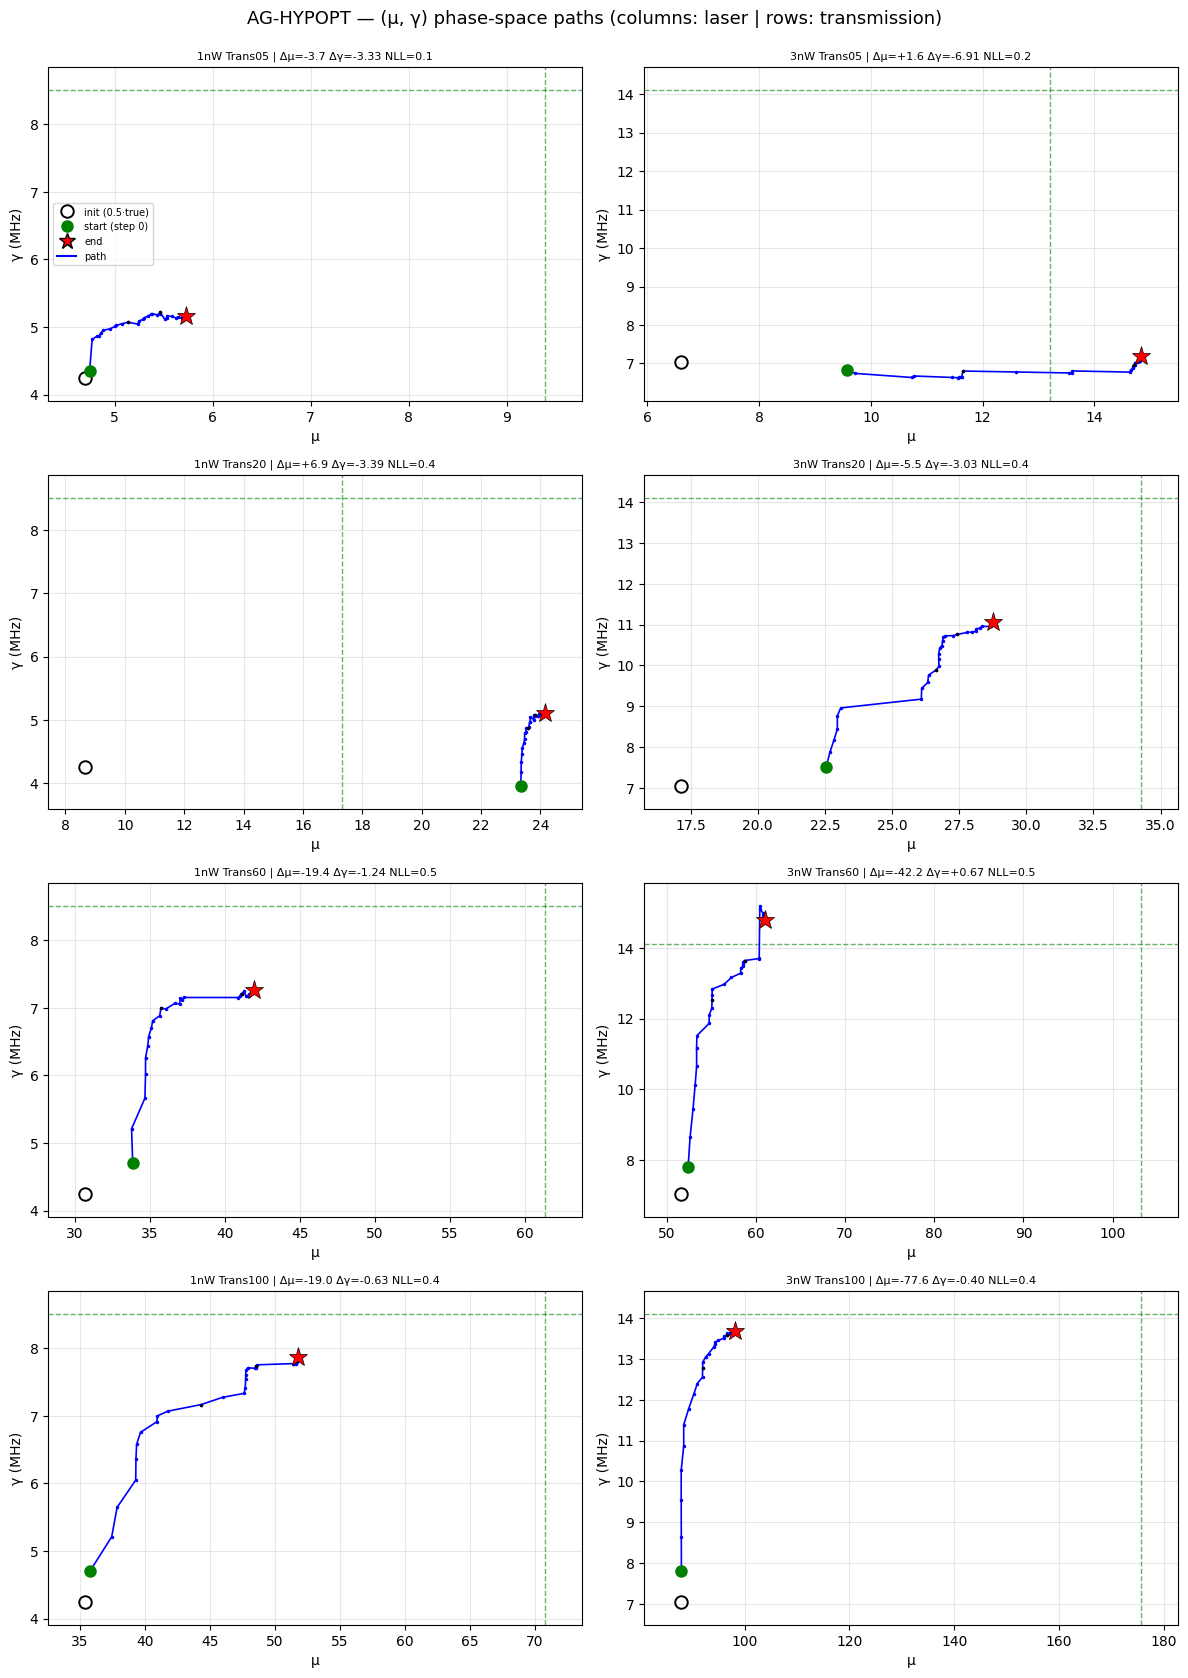

trial finished in 7.7 min
objective = 0.0831 ± 0.0200
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.73   -39.0 |     8.50    5.17   -39.2
1nW Trans20       17.32   24.17   +39.6 |     8.50    5.11   -39.9
1nW Trans60       61.37   41.95   -31.6 |     8.50    7.26   -14.6
1nW Trans100       70.82   51.77   -26.9 |     8.50    7.87    -7.4
3nW Trans05       13.20   14.84   +12.4 |    14.10    7.19   -49.0
3nW Trans20       34.28   28.74   -16.2 |    14.10   11.07   -21.5
3nW Trans60      103.20   61.01   -40.9 |    14.10   14.77    +4.8
3nW Trans100      175.71   98.10   -44.2 |    14.10   13.70    -2.9

weighted objective (T-graded, cap=1.0) = 0.0831 | diverged cells: 0
μ: RMSE 32.857 (rel 33.3%, bias -19.872) | γ: RMSE 3.204 (rel 28.0%, bias -2.284)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

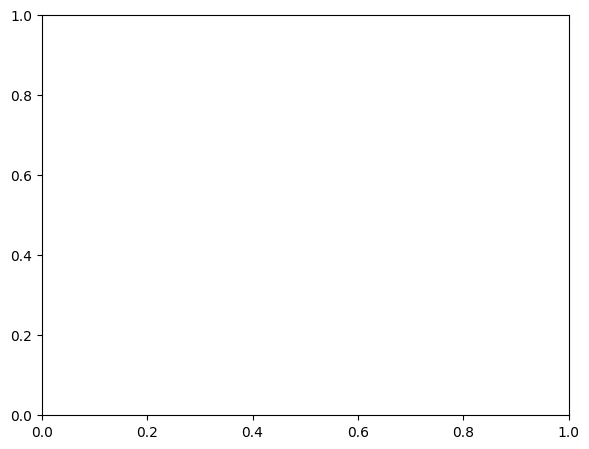

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0831 ± 0.0200, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 4.698, h_s_scale = 7.535 (highest-EI proposal).

Usual pattern: mu mixed-sign (1nW Trans20 +39.6 %, 3nW Trans05 +12.4 %; the rest -16 to -44 %), gamma
underestimated except a small overshoot at 3nW Trans60 (+4.8 %). Another plateau sample at 0.0831, close to
the plateau centroid.

The target plateau now has seven samples spanning 0.0803-0.0890 (mean ~0.0846) with no trend in h_f or h_s
inside the band; this trial adds 0.0831 in the middle. Best recorded is still exp6's 0.0803. Nothing here
changes the picture - the plateau is genuinely flat at the campaign's sampling precision.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 10 (target rule, h_f 4.698, h_s 7.535) scores objective 0.0831 ± 0.0200, a mid-plateau sample consistent with the flat 0.080-0.089 target band.
**Key insight:** Seven plateau samples now span 0.0803-0.0890 with no internal trend, cementing that the target-rule objective is flat/noise-limited across h_f ~3.5-5.5 and that exp6's 0.0803 remains the best.

Notes for Anuar (optional, not acted on): none new.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 10 (target rule, h_f 4.698, h_s 7.535) scores objective 0.0831 ± 0.0200, a mid-plateau sample consistent with the flat 0.080-0.089 target band."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Seven plateau samples now span 0.0803-0.0890 with no internal trend, cementing that the target-rule objective is flat/noise-limited across h_f ~3.5-5.5 and that exp6's 0.0803 remains the best."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_10 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_11.ipynb. Open it and follow its cells from the top.
